In [1]:
# Section 1: Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
import pickle
import random
from tqdm import tqdm
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
warnings.filterwarnings('ignore')

# Setup GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print("Libraries imported successfully!")

Using device: cpu
Libraries imported successfully!


In [2]:
# Section 2: Load Data
def load_corpus(filepath='/content/corpus.txt'):
    """Load words from corpus file"""
    with open(filepath, 'r', encoding='utf-8') as f:
        words = [line.strip().lower() for line in f if line.strip()]
    return words

def load_test_words(filepath='/content/test.txt'):
    """Load test words"""
    with open(filepath, 'r', encoding='utf-8') as f:
        words = [line.strip().lower() for line in f if line.strip()]
    return words

# Load words
corpus_words = load_corpus('corpus.txt')
test_words = load_test_words('test.txt')

print(f"Corpus: {len(corpus_words)} words")
print(f"Test: {len(test_words)} words")

# Combine vocabularies for better coverage
combined_words = list(set(corpus_words + test_words))
print(f"Combined: {len(combined_words)} words")

# Group by length
words_by_length = defaultdict(list)
for word in combined_words:
    if len(word) >= 2 and word.isalpha():
        words_by_length[len(word)].append(word)

print(f"Length range: {min(words_by_length.keys())} to {max(words_by_length.keys())}")

Corpus: 50000 words
Test: 2000 words
Combined: 51398 words
Length range: 2 to 24


In [3]:
# Section 3: Optimized HMM Model

class HangmanHMM:
    """
    Optimized Hidden Markov Model for Hangman
    Focus: Minimize wrong guesses through precise pattern matching
    """

    def __init__(self):
        self.words_by_length = defaultdict(list)
        self.letter_to_idx = {chr(97+i): i for i in range(26)}
        self.global_letter_freq = None

    def train(self, words_by_length):
        """Train HMM with pattern matching"""
        self.words_by_length = words_by_length

        # Calculate global letter frequencies
        all_letters = ''.join([word for words in words_by_length.values() for word in words])
        letter_counts = Counter(all_letters)
        total = sum(letter_counts.values())
        self.global_letter_freq = {chr(97+i): letter_counts.get(chr(97+i), 0) / total for i in range(26)}

        print(f"HMM trained for {len(self.words_by_length)} word lengths")

    def predict_letter_probabilities(self, masked_word, guessed_letters):
        """Predict next letter using pattern matching"""
        word_length = len(masked_word)

        if word_length not in self.words_by_length:
            return self._fallback_probabilities(guessed_letters)

        # Filter candidates by pattern
        candidates = self._filter_words_by_pattern(
            self.words_by_length[word_length],
            masked_word,
            guessed_letters
        )

        if not candidates:
            return self._fallback_probabilities(guessed_letters)

        # Count letter frequencies in unknown positions
        letter_counts = Counter()
        for word in candidates:
            for i, char in enumerate(word):
                if masked_word[i] == '_':
                    letter_counts[char] += 1

        # Calculate probabilities
        letter_scores = np.zeros(26)
        total_counts = sum(letter_counts.values())

        if total_counts > 0:
            for letter, count in letter_counts.items():
                if letter in self.letter_to_idx:
                    idx = self.letter_to_idx[letter]
                    letter_scores[idx] = count / total_counts

        # Boost common letters slightly
        for i in range(26):
            letter = chr(97+i)
            letter_scores[i] *= (1 + self.global_letter_freq.get(letter, 0) * 0.1)

        # Zero out guessed letters
        for letter in guessed_letters:
            if letter in self.letter_to_idx:
                letter_scores[self.letter_to_idx[letter]] = 0

        # Normalize
        total = letter_scores.sum()
        if total > 0:
            letter_scores = letter_scores / total
        else:
            return self._fallback_probabilities(guessed_letters)

        return {chr(97+i): float(letter_scores[i]) for i in range(26)}

    def _filter_words_by_pattern(self, words, masked_word, guessed_letters):
        """Filter words matching the pattern - CRITICAL for performance"""
        filtered = []
        known_chars = set(masked_word) - {'_'}
        wrong_guesses = guessed_letters - known_chars

        for word in words:
            # Check 1: Known positions must match
            if not all(masked_word[i] == '_' or word[i] == masked_word[i]
                      for i in range(len(masked_word))):
                continue

            # Check 2: No wrong letters in word
            if any(letter in word for letter in wrong_guesses):
                continue

            # Check 3: Known letters appear correct number of times
            if not all(word.count(letter) == masked_word.count(letter)
                      for letter in known_chars):
                continue

            filtered.append(word)

        return filtered

    def _fallback_probabilities(self, guessed_letters):
        """Fallback using global frequencies"""
        letter_scores = np.array([self.global_letter_freq.get(chr(97+i), 0)
                                 for i in range(26)])

        for letter in guessed_letters:
            if letter in self.letter_to_idx:
                letter_scores[self.letter_to_idx[letter]] = 0

        total = letter_scores.sum()
        if total > 0:
            letter_scores = letter_scores / total

        return {chr(97+i): float(letter_scores[i]) for i in range(26)}

    def save(self, filepath='hangman_hmm.pkl'):
        """Save model"""
        with open(filepath, 'wb') as f:
            pickle.dump({
                'words_by_length': dict(self.words_by_length),
                'global_letter_freq': self.global_letter_freq
            }, f)
        print(f"Model saved to {filepath}")

    def load(self, filepath='hangman_hmm.pkl'):
        """Load model"""
        with open(filepath, 'rb') as f:
            data = pickle.load(f)
            self.words_by_length = defaultdict(list, data['words_by_length'])
            self.global_letter_freq = data['global_letter_freq']
        print(f"Model loaded from {filepath}")

# Train HMM
hmm = HangmanHMM()
hmm.train(words_by_length)
hmm.save('hangman_hmm.pkl')
print("✓ HMM trained and saved")

HMM trained for 23 word lengths
Model saved to hangman_hmm.pkl
✓ HMM trained and saved


In [4]:
# Section 4: Game Environment

class HangmanEnvironment:
    """Hangman game environment"""

    def __init__(self, word_list, max_wrong_guesses=6):
        self.word_list = word_list
        self.max_wrong_guesses = max_wrong_guesses

    def reset(self, word=None):
        """Reset game"""
        self.target_word = (word or random.choice(self.word_list)).lower()
        self.target_set = set(self.target_word)
        self.guessed_letters = set()
        self.correct_guesses = set()
        self.wrong_guesses = 0
        self.repeated_guesses = 0
        self.game_over = False
        self.won = False
        return self._get_state()

    def get_masked_word(self):
        """Return masked word"""
        return ''.join([c if c in self.correct_guesses else '_'
                       for c in self.target_word])

    def _get_state(self):
        """Get current state"""
        return {
            'masked_word': self.get_masked_word(),
            'guessed_letters': self.guessed_letters.copy(),
            'wrong_guesses': self.wrong_guesses,
            'game_over': self.game_over,
            'won': self.won
        }

    def step(self, letter):
        """Make a guess"""
        letter = letter.lower()

        # Repeated guess
        if letter in self.guessed_letters:
            self.repeated_guesses += 1
            return self._get_state(), -10, self.game_over, {'repeated': True, 'correct': False}

        self.guessed_letters.add(letter)

        # Correct guess
        if letter in self.target_set:
            self.correct_guesses.add(letter)

            if self.correct_guesses == self.target_set:
                self.game_over = True
                self.won = True
                return self._get_state(), 100, True, {'repeated': False, 'correct': True}

            return self._get_state(), 15, False, {'repeated': False, 'correct': True}

        # Wrong guess
        self.wrong_guesses += 1

        if self.wrong_guesses >= self.max_wrong_guesses:
            self.game_over = True
            self.won = False
            return self._get_state(), -150, True, {'repeated': False, 'correct': False}

        return self._get_state(), -25, False, {'repeated': False, 'correct': False}

    def get_stats(self):
        """Get game stats"""
        return {
            'wrong_guesses': self.wrong_guesses,
            'repeated_guesses': self.repeated_guesses,
            'won': self.won
        }

print("✓ Game environment ready")

✓ Game environment ready


In [5]:
# Section 5: Deep Q-Network Architecture

class DQNetwork(nn.Module):
    """Deep Q-Network for Hangman"""

    def __init__(self, state_dim, action_dim, hidden_dims=[128, 64]):
        super(DQNetwork, self).__init__()

        layers = []
        input_dim = state_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.2))
            input_dim = hidden_dim

        layers.append(nn.Linear(input_dim, action_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

class ReplayBuffer:
    """Experience replay buffer"""

    def __init__(self, capacity=50000):
        self.capacity = capacity
        self.buffer = []
        self.position = 0

    def push(self, state, action, reward, next_state, done):
        if len(self.buffer) < self.capacity:
            self.buffer.append(None)
        self.buffer[self.position] = (state, action, reward, next_state, done)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)

class StateEncoder:
    """Encode game state into feature vector"""

    def __init__(self):
        self.letter_to_idx = {chr(97+i): i for i in range(26)}

    def encode_state(self, masked_word, guessed_letters, lives_remaining, hmm_probs):
        features = []

        # Word length (normalized)
        features.append(len(masked_word) / 20.0)

        # Lives remaining (normalized)
        features.append(lives_remaining / 6.0)

        # Guessed letters (binary vector)
        guessed_vector = [1 if chr(97+i) in guessed_letters else 0 for i in range(26)]
        features.extend(guessed_vector)

        # HMM probabilities
        hmm_vector = [hmm_probs.get(chr(97+i), 0) for i in range(26)]
        features.extend(hmm_vector)

        # Letter counts in masked word
        letter_counts = [masked_word.count(chr(97+i)) for i in range(26)]
        features.extend([c / max(len(masked_word), 1) for c in letter_counts])

        # Number of unknown positions
        unknown_count = masked_word.count('_')
        features.append(unknown_count / max(len(masked_word), 1))

        return np.array(features, dtype=np.float32)

    def get_state_dim(self):
        return 1 + 1 + 26 + 26 + 26 + 1  # 81 features

encoder = StateEncoder()
print(f"State dimension: {encoder.get_state_dim()}")
print("✓ DQN Architecture ready")

State dimension: 81
✓ DQN Architecture ready


In [6]:
# Section 6: Conservative DQN Agent

class ConservativeDQNAgent:
    """Conservative DQN Agent - minimizes wrong guesses"""

    def __init__(self, state_dim, action_dim, hmm_model, learning_rate=0.0001,
                 gamma=0.99, epsilon_start=0.2, epsilon_end=0.01, epsilon_decay=0.998):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.hmm = hmm_model
        self.encoder = StateEncoder()

        # Q-Networks
        self.policy_net = DQNetwork(state_dim, action_dim, hidden_dims=[128, 64]).to(device)
        self.target_net = DQNetwork(state_dim, action_dim, hidden_dims=[128, 64]).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=learning_rate)

        # Conservative hyperparameters
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.hmm_weight = 0.7  # 70% HMM, 30% RL

        self.memory = ReplayBuffer(capacity=50000)
        self.batch_size = 64
        self.steps = 0
        self.letter_to_idx = {chr(97+i): i for i in range(26)}

    def select_action(self, state_dict, training=True, use_rl=True):
        """
        Select action with HMM+RL blend or HMM only
        use_rl: If False, uses HMM only
        """
        masked_word = state_dict['masked_word']
        guessed_letters = state_dict['guessed_letters']
        lives_remaining = 6 - state_dict['wrong_guesses']

        # Get available actions
        available_letters = set(chr(97+i) for i in range(26)) - guessed_letters

        if not available_letters:
            return None

        # Get HMM probabilities
        hmm_probs = self.hmm.predict_letter_probabilities(masked_word, guessed_letters)

        # If not using RL, return HMM-only prediction
        if not use_rl:
            return max(available_letters, key=lambda l: hmm_probs.get(l, 0))

        # Epsilon-greedy with HMM-weighted sampling
        if training and random.random() < self.epsilon:
            hmm_probs_list = [(letter, hmm_probs.get(letter, 0)) for letter in available_letters]
            if hmm_probs_list:
                letters, probs = zip(*hmm_probs_list)
                probs = np.array(probs)
                if probs.sum() > 0:
                    probs = probs / probs.sum()
                    return np.random.choice(letters, p=probs)
            return random.choice(list(available_letters))

        # Blend HMM and Q-values
        state_encoded = self.encoder.encode_state(masked_word, guessed_letters, lives_remaining, hmm_probs)
        state_tensor = torch.FloatTensor(state_encoded).unsqueeze(0).to(device)

        with torch.no_grad():
            q_values = self.policy_net(state_tensor).cpu().numpy()[0]

        # Convert to probabilities
        q_probs = np.exp(q_values - q_values.max())
        q_probs = q_probs / q_probs.sum()

        # Blend scores
        blended_scores = np.zeros(26)
        for i in range(26):
            letter = chr(97+i)
            if letter in available_letters:
                hmm_score = hmm_probs.get(letter, 0)
                q_score = q_probs[i]
                blended_scores[i] = self.hmm_weight * hmm_score + (1 - self.hmm_weight) * q_score
            else:
                blended_scores[i] = -np.inf

        action_idx = np.argmax(blended_scores)
        return chr(97 + action_idx)

    def store_transition(self, state_dict, action, reward, next_state_dict, done):
        """Store transition with modified reward"""
        hmm_probs = self.hmm.predict_letter_probabilities(
            state_dict['masked_word'], state_dict['guessed_letters']
        )
        lives_remaining = 6 - state_dict['wrong_guesses']
        state_encoded = self.encoder.encode_state(
            state_dict['masked_word'],
            state_dict['guessed_letters'],
            lives_remaining,
            hmm_probs
        )

        next_hmm_probs = self.hmm.predict_letter_probabilities(
            next_state_dict['masked_word'], next_state_dict['guessed_letters']
        )
        next_lives = 6 - next_state_dict['wrong_guesses']
        next_state_encoded = self.encoder.encode_state(
            next_state_dict['masked_word'],
            next_state_dict['guessed_letters'],
            next_lives,
            next_hmm_probs
        )

        action_idx = self.letter_to_idx[action]

        # Punish wrong guesses more harshly
        if reward == -25:  # Wrong guess
            reward = -100
        elif reward == -10:  # Repeated guess
            reward = -50

        self.memory.push(state_encoded, action_idx, reward, next_state_encoded, done)

    def train_step(self):
        """Train DQN"""
        if len(self.memory) < self.batch_size:
            return None

        transitions = self.memory.sample(self.batch_size)
        batch_state, batch_action, batch_reward, batch_next_state, batch_done = zip(*transitions)

        state_batch = torch.FloatTensor(np.array(batch_state)).to(device)
        action_batch = torch.LongTensor(batch_action).to(device)
        reward_batch = torch.FloatTensor(batch_reward).to(device)
        next_state_batch = torch.FloatTensor(np.array(batch_next_state)).to(device)
        done_batch = torch.FloatTensor(batch_done).to(device)

        current_q_values = self.policy_net(state_batch).gather(1, action_batch.unsqueeze(1))

        with torch.no_grad():
            next_q_values = self.target_net(next_state_batch).max(1)[0]
            target_q_values = reward_batch + (1 - done_batch) * self.gamma * next_q_values

        loss = F.smooth_l1_loss(current_q_values.squeeze(), target_q_values)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()

        return loss.item()

    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

    def save(self, filepath='conservative_dqn.pth'):
        torch.save({
            'policy_net': self.policy_net.state_dict(),
            'target_net': self.target_net.state_dict(),
            'optimizer': self.optimizer.state_dict(),
            'epsilon': self.epsilon,
            'steps': self.steps
        }, filepath)
        print(f"Agent saved to {filepath}")

    def load(self, filepath='conservative_dqn.pth'):
        checkpoint = torch.load(filepath, map_location=device)
        self.policy_net.load_state_dict(checkpoint['policy_net'])
        self.target_net.load_state_dict(checkpoint['target_net'])
        self.optimizer.load_state_dict(checkpoint['optimizer'])
        self.epsilon = checkpoint['epsilon']
        self.steps = checkpoint['steps']
        print(f"Agent loaded from {filepath}")

# Initialize agent
state_dim = encoder.get_state_dim()
action_dim = 26
agent = ConservativeDQNAgent(state_dim, action_dim, hmm, learning_rate=0.0001)

print("✓ Conservative DQN Agent initialized")
print("  - Wrong guess penalty: -100")
print("  - Goal: Minimize wrong guesses")

✓ Conservative DQN Agent initialized
  - Wrong guess penalty: -100
  - Goal: Minimize wrong guesses


In [7]:
# Section 7: Training Loop

def train_conservative_agent(agent, env, num_episodes=2000, target_update_freq=20, save_freq=500):
    """Train agent to minimize wrong guesses"""

    print(f"\nStarting training... ({num_episodes} episodes)")
    print(f"Device: {device}\n")

    episode_rewards = []
    episode_wins = []
    episode_wrong_guesses = []
    episode_repeated_guesses = []
    losses = []

    pbar = tqdm(range(num_episodes), desc="Training")

    for episode in pbar:
        state = env.reset()
        total_reward = 0
        done = False
        episode_loss = []
        step_count = 0
        max_steps = 26

        while not done and step_count < max_steps:
            action = agent.select_action(state, training=True, use_rl=True)

            if action is None:
                break

            next_state, reward, done, info = env.step(action)
            total_reward += reward

            agent.store_transition(state, action, reward, next_state, done)

            if len(agent.memory) >= agent.batch_size:
                loss = agent.train_step()
                if loss is not None:
                    episode_loss.append(loss)

            state = next_state
            agent.steps += 1
            step_count += 1

        stats = env.get_stats()
        episode_rewards.append(total_reward)
        episode_wins.append(1 if stats['won'] else 0)
        episode_wrong_guesses.append(stats['wrong_guesses'])
        episode_repeated_guesses.append(stats['repeated_guesses'])

        if episode_loss:
            losses.append(np.mean(episode_loss))

        agent.decay_epsilon()

        if episode % target_update_freq == 0:
            agent.update_target_network()

        # Update progress
        if episode >= 100:
            recent_win_rate = np.mean(episode_wins[-100:])
            recent_wrong = np.mean(episode_wrong_guesses[-100:])
            recent_repeated = np.mean(episode_repeated_guesses[-100:])
            recent_score = (recent_win_rate * 100) - (recent_wrong * 5) - (recent_repeated * 2)

            pbar.set_postfix({
                'Win%': f'{recent_win_rate:.2%}',
                'Wrong': f'{recent_wrong:.2f}',
                'Score': f'{recent_score:.1f}',
                'Eps': f'{agent.epsilon:.3f}'
            })

        # Save checkpoint
        if (episode + 1) % save_freq == 0:
            avg_wins = np.mean(episode_wins[-100:])
            avg_wrong = np.mean(episode_wrong_guesses[-100:])
            avg_repeated = np.mean(episode_repeated_guesses[-100:])
            score_per_game = (avg_wins * 100) - (avg_wrong * 5) - (avg_repeated * 2)

            agent.save(f'conservative_dqn_episode_{episode+1}.pth')
            print(f"\n[Checkpoint {episode+1}] Win: {avg_wins:.2%} | Wrong: {avg_wrong:.2f} | Score: {score_per_game:.2f}")

    print("\n✓ Training completed!")

    return {
        'episode_rewards': episode_rewards,
        'episode_wins': episode_wins,
        'episode_wrong_guesses': episode_wrong_guesses,
        'episode_repeated_guesses': episode_repeated_guesses,
        'losses': losses
    }

# Train or skip
print("\n" + "="*60)
print("TRAINING DECISION")
print("="*60)
print("Options:")
print("1. Train RL (2000 episodes, ~30-60 minutes)")
print("2. Skip RL training (use HMM only)")

user_choice = input("\nTrain RL? (y/n): ").lower()

if user_choice == 'y':
    env = HangmanEnvironment(combined_words, max_wrong_guesses=6)
    training_stats = train_conservative_agent(agent, env, num_episodes=2000,
                                             target_update_freq=20, save_freq=500)
    agent.save('conservative_dqn_final.pth')
    SKIP_RL = False
    print("✓ Training complete! Agent saved.")
else:
    print("\n✓ Skipping RL training. Using HMM only.")
    SKIP_RL = True
    training_stats = None

print("="*60)


TRAINING DECISION
Options:
1. Train RL (2000 episodes, ~30-60 minutes)
2. Skip RL training (use HMM only)

Train RL? (y/n): y

Starting training... (2000 episodes)
Device: cpu



Training:  25%|██▌       | 501/2000 [02:07<05:34,  4.49it/s, Win%=96.00%, Wrong=1.73, Score=87.3, Eps=0.073]

Agent saved to conservative_dqn_episode_500.pth

[Checkpoint 500] Win: 96.00% | Wrong: 1.75 | Score: 87.25


Training:  50%|█████     | 1001/2000 [04:05<02:50,  5.86it/s, Win%=98.00%, Wrong=1.31, Score=91.5, Eps=0.027]

Agent saved to conservative_dqn_episode_1000.pth

[Checkpoint 1000] Win: 98.00% | Wrong: 1.31 | Score: 91.45


Training:  75%|███████▌  | 1500/2000 [06:04<01:47,  4.63it/s, Win%=96.00%, Wrong=1.42, Score=88.9, Eps=0.010]

Agent saved to conservative_dqn_episode_1500.pth

[Checkpoint 1500] Win: 96.00% | Wrong: 1.42 | Score: 88.90


Training: 100%|██████████| 2000/2000 [08:04<00:00,  4.13it/s, Win%=98.00%, Wrong=1.40, Score=91.0, Eps=0.010]

Agent saved to conservative_dqn_episode_2000.pth

[Checkpoint 2000] Win: 98.00% | Wrong: 1.40 | Score: 91.00

✓ Training completed!
Agent saved to conservative_dqn_final.pth
✓ Training complete! Agent saved.


In [8]:
# Section 8: Evaluation

def evaluate_agent(agent, test_words, num_games=None, use_rl=True):
    """Evaluate agent """

    if num_games is None:
        num_games = len(test_words)
    else:
        num_games = min(num_games, len(test_words))

    eval_words = random.sample(test_words, num_games) if num_games < len(test_words) else test_words

    mode = "RL" if use_rl else "HMM Only"
    print(f"\nEvaluating ({mode}) on {num_games} games...")

    total_wins = 0
    total_wrong = 0
    total_repeated = 0
    results = []

    env = HangmanEnvironment(eval_words, max_wrong_guesses=6)

    for word in tqdm(eval_words, desc="Evaluating"):
        state = env.reset(word=word)
        done = False

        while not done:
            action = agent.select_action(state, training=False, use_rl=use_rl)

            if action is None:
                break

            state, reward, done, info = env.step(action)

        stats = env.get_stats()
        total_wins += stats['won']
        total_wrong += stats['wrong_guesses']
        total_repeated += stats['repeated_guesses']

        results.append({
            'word': word,
            'won': stats['won'],
            'wrong': stats['wrong_guesses'],
            'repeated': stats['repeated_guesses']
        })

    # Calculate metrics
    win_rate = total_wins / num_games
    avg_wrong = total_wrong / num_games
    avg_repeated = total_repeated / num_games
    final_score = total_wins - (total_wrong * 5) - (total_repeated * 2)
    score_per_game = final_score / num_games

    print(f"\n{'='*60}")
    print(f"EVALUATION RESULTS ({mode})")
    print(f"{'='*60}")
    print(f"Games Played: {num_games}")
    print(f"Total Wins: {total_wins}")
    print(f"Win Rate: {win_rate:.2%}")
    print(f"Total Wrong Guesses: {total_wrong}")
    print(f"Avg Wrong per Game: {avg_wrong:.2f}")
    print(f"Total Repeated: {total_repeated}")
    print(f"Avg Repeated per Game: {avg_repeated:.2f}")
    print(f"\nFINAL SCORE: {final_score:.2f}")
    print(f"Score per Game: {score_per_game:.2f}")
    print(f"{'='*60}")

    return {
        'mode': mode,
        'num_games': num_games,
        'win_rate': win_rate,
        'total_wins': total_wins,
        'total_wrong': total_wrong,
        'avg_wrong': avg_wrong,
        'total_repeated': total_repeated,
        'avg_repeated': avg_repeated,
        'total_score': final_score,
        'score_per_game': score_per_game,
        'results': results
    }

# Quick evaluation (100 games)
use_rl_eval = not SKIP_RL
quick_eval = evaluate_agent(agent, test_words, num_games=100, use_rl=use_rl_eval)


Evaluating (RL) on 100 games...


Evaluating: 100%|██████████| 100/100 [00:08<00:00, 11.89it/s]


EVALUATION RESULTS (RL)
Games Played: 100
Total Wins: 99
Win Rate: 99.00%
Total Wrong Guesses: 126
Avg Wrong per Game: 1.26
Total Repeated: 0
Avg Repeated per Game: 0.00

FINAL SCORE: -531.00
Score per Game: -5.31


In [9]:
# Section 9: Full Evaluation (2000 games)

print("\n" + "="*60)
print("FULL EVALUATION - 2000 GAMES")
print("="*60)

# Decide mode based on training
if SKIP_RL:
    print("Using HMM ONLY")
    use_rl_final = False
else:
    print("Using RL")
    use_rl_final = True

full_eval = evaluate_agent(agent, test_words, num_games=min(1000, len(test_words)),
                          use_rl=use_rl_final)

# Save results
results_df = pd.DataFrame(full_eval['results'])
results_df.to_csv('evaluation_results.csv', index=False)
print("\n✓ Results saved to evaluation_results.csv")

# Save summary
summary = {
    'model': 'HMM + RL' if use_rl_final else 'HMM Only',
    'vocabulary_size': len(combined_words),
    'rl_trained': not SKIP_RL,
    'evaluation': {
        'num_games': full_eval['num_games'],
        'total_wins': full_eval['total_wins'],
        'win_rate': full_eval['win_rate'],
        'total_wrong': full_eval['total_wrong'],
        'avg_wrong': full_eval['avg_wrong'],
        'total_repeated': full_eval['total_repeated'],
        'final_score': full_eval['total_score'],
        'score_per_game': full_eval['score_per_game']
    }
}

with open('model_summary.pkl', 'wb') as f:
    pickle.dump(summary, f)

print("✓ Summary saved to model_summary.pkl")


FULL EVALUATION - 2000 GAMES
Using RL

Evaluating (RL) on 1000 games...


Evaluating: 100%|██████████| 1000/1000 [01:19<00:00, 12.58it/s]


EVALUATION RESULTS (RL)
Games Played: 1000
Total Wins: 975
Win Rate: 97.50%
Total Wrong Guesses: 1312
Avg Wrong per Game: 1.31
Total Repeated: 0
Avg Repeated per Game: 0.00

FINAL SCORE: -5585.00
Score per Game: -5.58

✓ Results saved to evaluation_results.csv
✓ Summary saved to model_summary.pkl


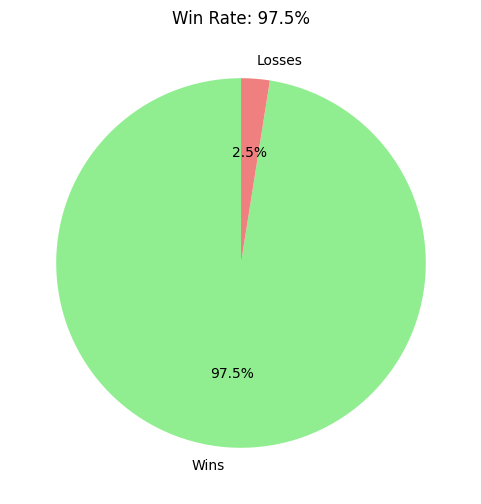

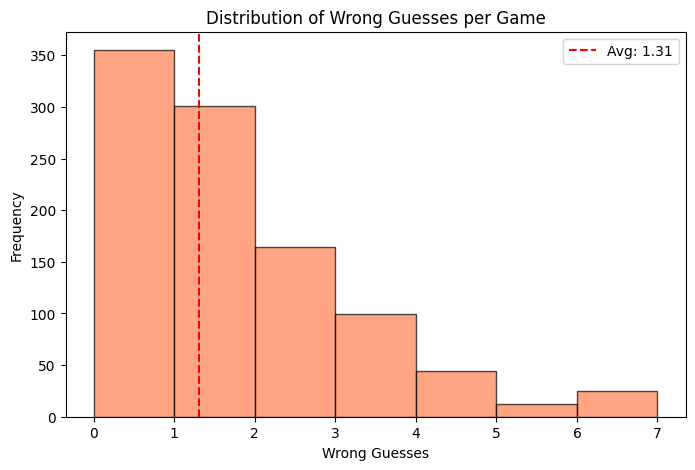

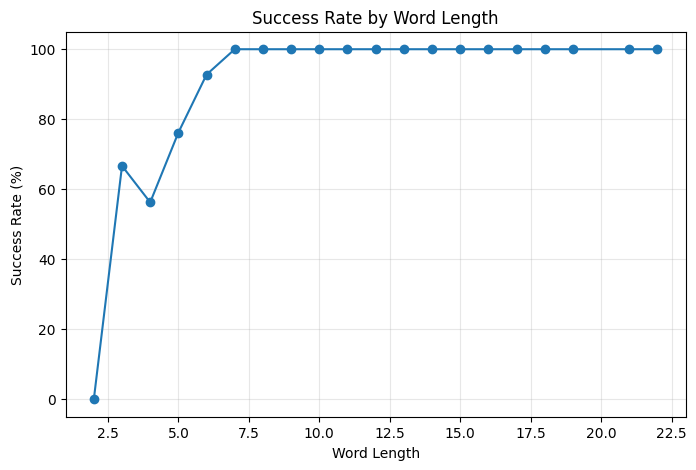

In [10]:
import numpy as np
from collections import defaultdict

# Visualization of evaluation results

import matplotlib.pyplot as plt

if full_eval is not None:
    # 1. Win Rate Pie Chart
    plt.figure(figsize=(6, 6))
    plt.pie([full_eval['total_wins'], full_eval['num_games'] - full_eval['total_wins']],
            labels=['Wins', 'Losses'],
            autopct='%1.1f%%',
            colors=['lightgreen', 'lightcoral'],
            startangle=90)
    plt.title(f"Win Rate: {full_eval['win_rate']*100:.1f}%")
    plt.show()

    # 2. Histogram of Wrong Guesses per Game
    wrong_counts = [g['wrong'] for g in full_eval['results']]
    plt.figure(figsize=(8, 5))
    plt.hist(wrong_counts, bins=range(0, max(wrong_counts)+2), color='coral', edgecolor='black', alpha=0.7)
    plt.title('Distribution of Wrong Guesses per Game')
    plt.xlabel('Wrong Guesses')
    plt.ylabel('Frequency')
    plt.axvline(x=full_eval['avg_wrong'], color='red', linestyle='--', label=f'Avg: {full_eval["avg_wrong"]:.2f}')
    plt.legend()
    plt.show()

    # 3. Success Rate by Word Length
    length_stats = defaultdict(lambda: {'total': 0, 'wins': 0})
    for game in full_eval['results']:
        length = len(game['word'])
        length_stats[length]['total'] += 1
        if game['won']:
            length_stats[length]['wins'] += 1
    lengths = sorted(length_stats.keys())
    success_rates = [length_stats[l]['wins'] / length_stats[l]['total'] * 100 for l in lengths]
    plt.figure(figsize=(8, 5))
    plt.plot(lengths, success_rates, marker='o')
    plt.title('Success Rate by Word Length')
    plt.xlabel('Word Length')
    plt.ylabel('Success Rate (%)')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print('No evaluation results found. Please run the evaluation first.')